# 4ext. Regression Concept Drift Streams: HATR vs FIMTDD and ARF

This notebook extends **Tutorial 4** (Simulating concept drifts with the DriftStream API) to the **regression** setting, using `HoeffdingAdaptiveTreeRegressor` (HATR) as the main learner.

HATR is a regression Hoeffding Tree that places an **ADWIN** drift detector at every internal node. When drift is detected in a subtree, an alternate subtree is grown in the background and a z-test decides whether to swap it in. This makes HATR intrinsically adaptive without needing an external ensemble.

We compare HATR against **FIMTDD** (no drift detection), **ARFFIMTDD** (ensemble with per-tree ADWIN), and **AdaptiveRandomForestRegressor** (full ARF ensemble).

Scenarios: stable stream, single abrupt drift, single gradual drift, multiple abrupt drifts, ADWIN δ sensitivity.

**Note:** run cells in order from a fresh kernel. If you see `Class not found`, restart the kernel and run all cells.

## 0 — Setup: classpath (must run before any CapyMOA import)

In [1]:
import os, sys
import jpype  # only for addClassPath, does not start the JVM

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), (
    f'JAR not found: {HATR_JAR}\n'
    'run: cd implementation/hatr-moa && mvn package -DskipTests'
)

if jpype.isJVMStarted():
    print('JVM already started, restart the kernel and run all cells')
else:
    jpype.addClassPath(HATR_JAR)
    print(f'classpath: {HATR_JAR}')

# hatr_capymoa package lives one level above this notebook
sys.path.insert(0, os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation')))

classpath: /Users/andreazhang/Desktop/sda/2025-2026_Regression-Models-in-CapyMOA/andrea_zhang/implementation/hatr-moa/target/hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar


## 1 — Imports

In [2]:
import pandas as pd

from hatr_capymoa import HoeffdingAdaptiveTreeRegressor
from capymoa.regressor import FIMTDD, ARFFIMTDD, AdaptiveRandomForestRegressor
from capymoa.stream.generator import HyperPlaneRegression
from capymoa.stream.drift import DriftStream, AbruptDrift, GradualDrift
from capymoa.evaluation import prequential_evaluation_multiple_learners
from capymoa.evaluation.visualization import plot_windowed_results

# Shared evaluation parameters
WINDOW_SIZE   = 500
MAX_INSTANCES = 10_000

## 2 — Stable stream (no drift)

We first establish a **baseline**: all learners evaluated on a `HyperPlaneRegression` stream with **no concept drift** (`magnitude_of_change=0.0`).

- `HyperPlaneRegression` generates a regression problem where the target is a weighted sum of 10 features (coefficients sampled at stream creation time).
- With `magnitude_of_change=0.0` the hyperplane is fixed, so the concept is stationary.

On a stable stream we expect all learners to converge to similar RMSE. Differences reflect each model's inductive bias and capacity, not drift handling.

Stable stream — cumulative metrics (lower RMSE/MAE, higher R² is better):


,RMSE,MAE,R²
Learner,,,
HATR,19.1041,12.5933,0.9212
FIMTDD,25.3373,14.4565,0.8613
ARFFIMTDD,61.7995,46.3018,0.1751
ARF,52.1848,41.8583,0.4118


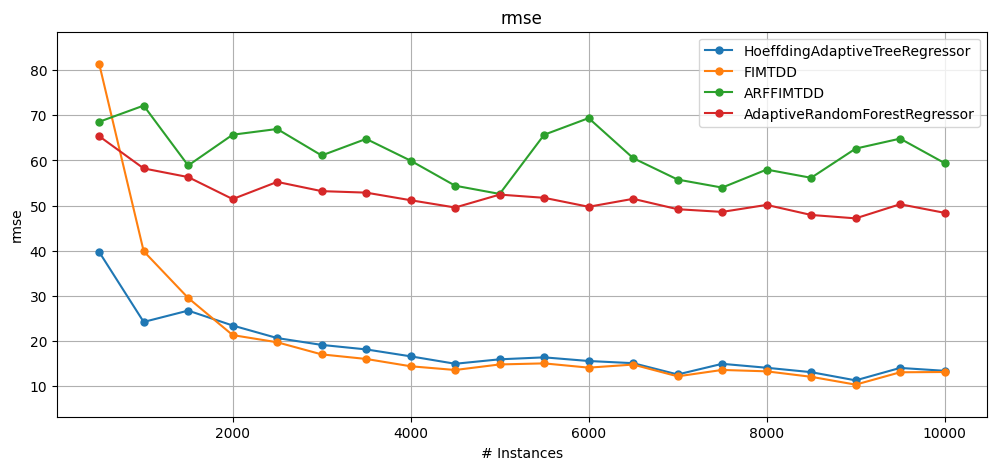

In [3]:
stream_stable = HyperPlaneRegression(instance_random_seed=1, magnitude_of_change=0.0)
schema = stream_stable.get_schema()

learners_stable = {
    'HATR':      HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1, bootstrap_sampling=False),
    'FIMTDD':    FIMTDD(schema=schema),
    'ARFFIMTDD': ARFFIMTDD(schema=schema),
    'ARF':       AdaptiveRandomForestRegressor(schema=schema),
}

results_stable = prequential_evaluation_multiple_learners(
    stream_stable, learners_stable,
    window_size=WINDOW_SIZE, max_instances=MAX_INSTANCES
)

summary_stable = pd.DataFrame([
    {'Learner': name,
     'RMSE': r.cumulative.rmse(),
     'MAE':  r.cumulative.mae(),
     'R²':   r.cumulative.r2()}
    for name, r in results_stable.items()
]).set_index('Learner').round(4)

print('Stable stream — cumulative metrics (lower RMSE/MAE, higher R² is better):')
display(summary_stable)

plot_windowed_results(
    results_stable['HATR'], results_stable['FIMTDD'],
    results_stable['ARFFIMTDD'], results_stable['ARF'],
    metric='rmse'
)

## 3 — Single abrupt drift

We now introduce a **single abrupt drift** at position 5000: the hyperplane changes instantaneously from `seed=1` to `seed=42`.

- `DriftStream` with `AbruptDrift(position=5000)` uses MOA's `ConceptDriftStream` under the hood.
- The drift position is stored in the stream's metadata and automatically marked on the windowed RMSE plot.

**Expected behaviour:**
- FIMTDD has no drift detection: after the drift it gradually adapts through normal Hoeffding Tree splits, which is slow.
- HATR detects the drift via per-node ADWIN and starts building alternate subtrees immediately, achieving faster recovery.
- ARFFIMTDD and ARF rely on ensemble diversity and ADWIN at tree level; recovery speed depends on the ensemble's reset mechanism.

Abrupt drift at position 5000 — cumulative metrics:


,RMSE,MAE,R²
Learner,,,
HATR,20.5824,13.5821,0.9053
FIMTDD,34.0476,23.7188,0.7408
ARFFIMTDD,60.4752,45.8268,0.1823
ARF,48.8100,38.5688,0.4673



Stream drift metadata: generators.HyperplaneGeneratorForRegression,AbruptDrift(position=5000),generators.HyperplaneGeneratorForRegression-i42


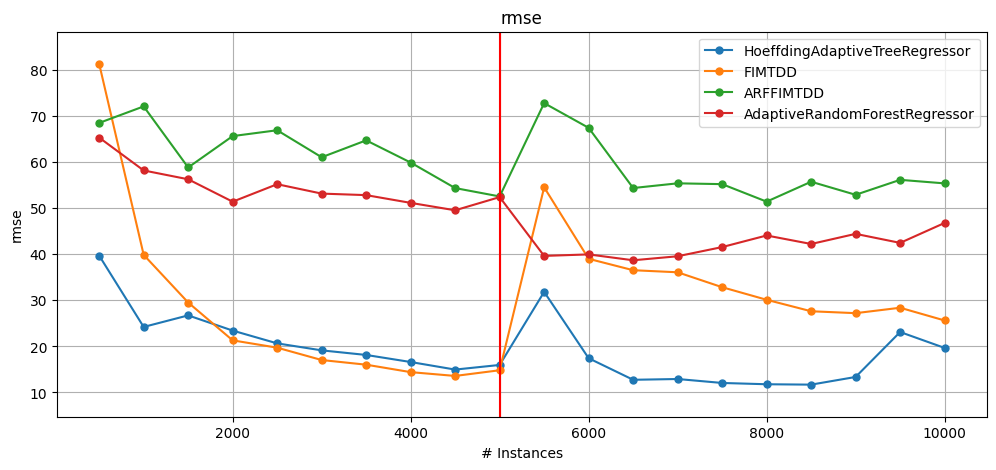

In [4]:
DRIFT_POS = 5_000

stream_abrupt = DriftStream(stream=[
    HyperPlaneRegression(instance_random_seed=1,  magnitude_of_change=0.0),
    AbruptDrift(position=DRIFT_POS),
    HyperPlaneRegression(instance_random_seed=42, magnitude_of_change=0.0),
])
schema = stream_abrupt.get_schema()

learners_abrupt = {
    'HATR':      HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1, bootstrap_sampling=False),
    'FIMTDD':    FIMTDD(schema=schema),
    'ARFFIMTDD': ARFFIMTDD(schema=schema),
    'ARF':       AdaptiveRandomForestRegressor(schema=schema),
}

results_abrupt = prequential_evaluation_multiple_learners(
    stream_abrupt, learners_abrupt,
    window_size=WINDOW_SIZE, max_instances=MAX_INSTANCES
)

summary_abrupt = pd.DataFrame([
    {'Learner': name,
     'RMSE': r.cumulative.rmse(),
     'MAE':  r.cumulative.mae(),
     'R²':   r.cumulative.r2()}
    for name, r in results_abrupt.items()
]).set_index('Learner').round(4)

print(f'Abrupt drift at position {DRIFT_POS} — cumulative metrics:')
display(summary_abrupt)

print(f'\nStream drift metadata: {stream_abrupt}')

plot_windowed_results(
    results_abrupt['HATR'], results_abrupt['FIMTDD'],
    results_abrupt['ARFFIMTDD'], results_abrupt['ARF'],
    metric='rmse'
)

## 4 — Single gradual drift

We replace the abrupt drift with a **gradual drift**: the two hyperplanes are mixed over a window of 2000 instances centred at position 5000 (`start=4000, end=6000`).

- `GradualDrift(position=5000, width=2000)` linearly interpolates the probability of drawing from the new concept.
- Gradual drift is harder for all learners because the distribution changes slowly, making it less obvious when to trigger a reset.
- HATR's ADWIN detects statistically significant changes in per-node error distributions: with a slow drift it may take longer to trigger, but avoids false positives on noise.

Gradual drift (position=5000, width=2000) — cumulative metrics:


,RMSE,MAE,R²
Learner,,,
HATR,27.1747,19.5821,0.8349
FIMTDD,35.6358,25.0293,0.7161
ARFFIMTDD,59.9188,45.4288,0.1974
ARF,49.9237,39.4642,0.4428



Stream drift metadata: generators.HyperplaneGeneratorForRegression,GradualDrift(position=5000, start=4000, end=6000, width=2000),generators.HyperplaneGeneratorForRegression-i42


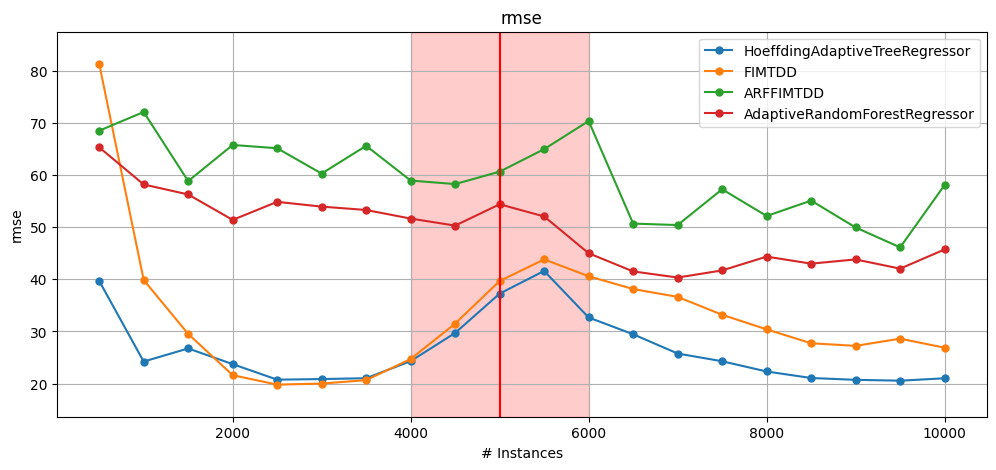

In [5]:
DRIFT_CENTER = 5_000
DRIFT_WIDTH  = 2_000

stream_gradual = DriftStream(stream=[
    HyperPlaneRegression(instance_random_seed=1,  magnitude_of_change=0.0),
    GradualDrift(position=DRIFT_CENTER, width=DRIFT_WIDTH),
    HyperPlaneRegression(instance_random_seed=42, magnitude_of_change=0.0),
])
schema = stream_gradual.get_schema()

learners_gradual = {
    'HATR':      HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1, bootstrap_sampling=False),
    'FIMTDD':    FIMTDD(schema=schema),
    'ARFFIMTDD': ARFFIMTDD(schema=schema),
    'ARF':       AdaptiveRandomForestRegressor(schema=schema),
}

results_gradual = prequential_evaluation_multiple_learners(
    stream_gradual, learners_gradual,
    window_size=WINDOW_SIZE, max_instances=MAX_INSTANCES
)

summary_gradual = pd.DataFrame([
    {'Learner': name,
     'RMSE': r.cumulative.rmse(),
     'MAE':  r.cumulative.mae(),
     'R²':   r.cumulative.r2()}
    for name, r in results_gradual.items()
]).set_index('Learner').round(4)

print(f'Gradual drift (position={DRIFT_CENTER}, width={DRIFT_WIDTH}) — cumulative metrics:')
display(summary_gradual)

print(f'\nStream drift metadata: {stream_gradual}')

plot_windowed_results(
    results_gradual['HATR'], results_gradual['FIMTDD'],
    results_gradual['ARFFIMTDD'], results_gradual['ARF'],
    metric='rmse'
)

## 5 — Multiple abrupt drifts

We simulate a stream with **three abrupt drifts**, each after 2500 instances. The fourth concept is the same as the first (recurring concept).

This scenario tests how well each learner maintains low error across multiple drift events:
- FIMTDD will lag at each drift.
- HATR should recover quickly after each drift thanks to per-node ADWIN.
- On the recurring concept, HATR may benefit from residual structure still present in the alternate subtrees.

Multiple abrupt drifts (3 drifts, 4 concepts) — cumulative metrics:


,RMSE,MAE,R²
Learner,,,
HATR,22.4210,15.1499,0.8866
FIMTDD,35.6561,25.5460,0.7132
ARFFIMTDD,60.7967,46.0989,0.1663
ARF,54.1799,43.3139,0.3379



Stream drift metadata:
generators.HyperplaneGeneratorForRegression,AbruptDrift(position=2500),generators.HyperplaneGeneratorForRegression-i42,AbruptDrift(position=5000),generators.HyperplaneGeneratorForRegression-i7,AbruptDrift(position=7500),generators.HyperplaneGeneratorForRegression


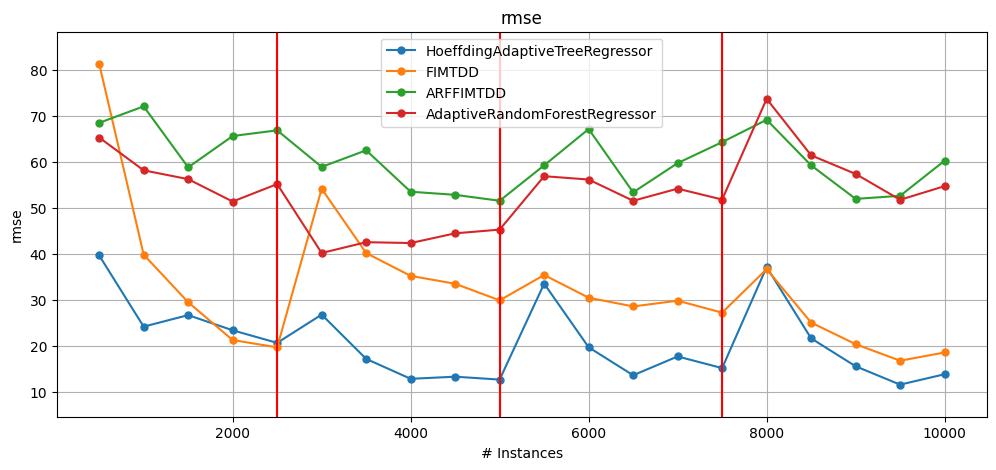

In [6]:
CONCEPT_LEN = 2_500
MAX_MULTI   = CONCEPT_LEN * 4

stream_multi = DriftStream(stream=[
    HyperPlaneRegression(instance_random_seed=1,  magnitude_of_change=0.0),
    AbruptDrift(position=CONCEPT_LEN * 1),
    HyperPlaneRegression(instance_random_seed=42, magnitude_of_change=0.0),
    AbruptDrift(position=CONCEPT_LEN * 2),
    HyperPlaneRegression(instance_random_seed=7,  magnitude_of_change=0.0),
    AbruptDrift(position=CONCEPT_LEN * 3),
    HyperPlaneRegression(instance_random_seed=1,  magnitude_of_change=0.0),  # recurring concept
])
schema = stream_multi.get_schema()

learners_multi = {
    'HATR':      HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1, bootstrap_sampling=False),
    'FIMTDD':    FIMTDD(schema=schema),
    'ARFFIMTDD': ARFFIMTDD(schema=schema),
    'ARF':       AdaptiveRandomForestRegressor(schema=schema),
}

results_multi = prequential_evaluation_multiple_learners(
    stream_multi, learners_multi,
    window_size=WINDOW_SIZE, max_instances=MAX_MULTI
)

summary_multi = pd.DataFrame([
    {'Learner': name,
     'RMSE': r.cumulative.rmse(),
     'MAE':  r.cumulative.mae(),
     'R²':   r.cumulative.r2()}
    for name, r in results_multi.items()
]).set_index('Learner').round(4)

print('Multiple abrupt drifts (3 drifts, 4 concepts) — cumulative metrics:')
display(summary_multi)

print(f'\nStream drift metadata:\n{stream_multi}')

plot_windowed_results(
    results_multi['HATR'], results_multi['FIMTDD'],
    results_multi['ARFFIMTDD'], results_multi['ARF'],
    metric='rmse'
)

## 6 — ADWIN δ sensitivity analysis

HATR's drift sensitivity is controlled by the `adwin_delta` parameter (the ADWIN false-alarm probability). A smaller δ makes ADWIN more conservative (fewer, more confident detections), while a larger δ makes it more reactive (triggers sooner, but more false positives).

We compare three values on the single-abrupt-drift scenario:
| δ | Behaviour |
|---|---|
| `1e-5` | very conservative: detects only strong drifts |
| `0.002` | default: balanced sensitivity |
| `0.01` | more reactive: faster recovery, higher false alarm rate |

The windowed RMSE plot shows the trade-off between recovery speed and noise.

ADWIN δ sensitivity — cumulative metrics:


,RMSE,MAE,R²
ADWIN δ,,,
HATR (δ=1e-5),19.7067,12.9112,0.9132
HATR (δ=0.002),20.5824,13.5821,0.9053
HATR (δ=0.01),20.1106,12.9107,0.9096


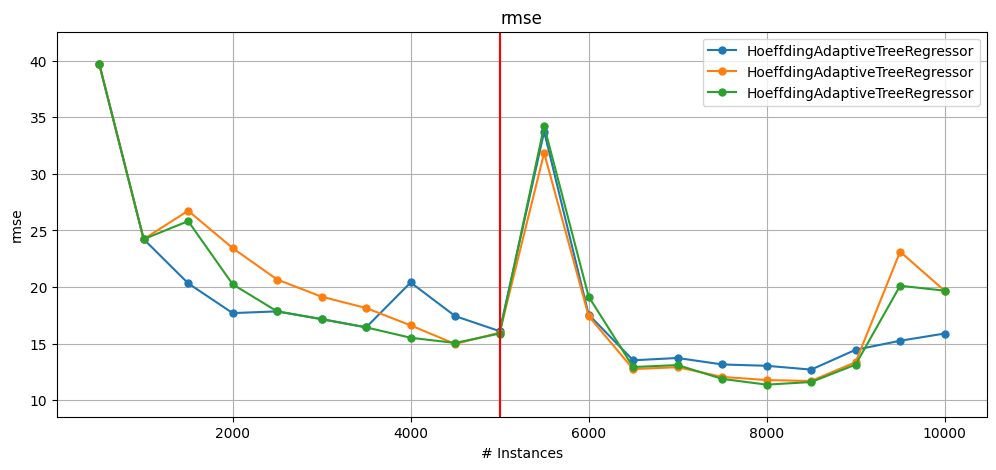

In [7]:
stream_sens = DriftStream(stream=[
    HyperPlaneRegression(instance_random_seed=1,  magnitude_of_change=0.0),
    AbruptDrift(position=5_000),
    HyperPlaneRegression(instance_random_seed=42, magnitude_of_change=0.0),
])
schema = stream_sens.get_schema()

learners_sens = {
    'HATR (δ=1e-5)':  HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1,
                                                      bootstrap_sampling=False, adwin_delta=1e-5),
    'HATR (δ=0.002)': HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1,
                                                      bootstrap_sampling=False, adwin_delta=0.002),
    'HATR (δ=0.01)':  HoeffdingAdaptiveTreeRegressor(schema=schema, random_seed=1,
                                                      bootstrap_sampling=False, adwin_delta=0.01),
}

results_sens = prequential_evaluation_multiple_learners(
    stream_sens, learners_sens,
    window_size=WINDOW_SIZE, max_instances=MAX_INSTANCES
)

summary_sens = pd.DataFrame([
    {'ADWIN δ': name,
     'RMSE': r.cumulative.rmse(),
     'MAE':  r.cumulative.mae(),
     'R²':   r.cumulative.r2()}
    for name, r in results_sens.items()
]).set_index('ADWIN δ').round(4)

print('ADWIN δ sensitivity — cumulative metrics:')
display(summary_sens)

plot_windowed_results(
    results_sens['HATR (δ=1e-5)'],
    results_sens['HATR (δ=0.002)'],
    results_sens['HATR (δ=0.01)'],
    metric='rmse'
)

## 7 — Summary

| Scenario | Key observation |
|---|---|
| Stable | All learners converge; HATR and FIMTDD are competitive single-tree models |
| Abrupt drift | HATR recovers faster than FIMTDD; ADWIN triggers subtree replacement at the affected nodes |
| Gradual drift | HATR adapts progressively; FIMTDD adapts through regular splits (slower) |
| Multiple drifts | HATR accumulates an advantage with each successive drift event |
| ADWIN δ | Larger δ means faster recovery but noisier; smaller δ is more conservative |

### Key takeaways

- HATR's per-node ADWIN makes it specifically suited for **regression streams with concept drift**.
- On stable streams, HATR behaves like a standard FIMTDD (the ADWIN detector adds minimal overhead when no drift is present).
- The default `adwin_delta=0.002` is a reasonable starting point; decrease it in noisy streams to avoid false alarms.
- For comparison with Tutorial 4 (classification), the CapyMOA `DriftStream` API is identical regardless of whether the learner is a classifier or a regressor.